# DQN with OpenSpiel 2048

This notebook shows how to train a **Deep Q-Network (DQN)** agent on the [**2048** game](https://2048game.com/) from **OpenSpiel**.

What this notebook covers:
- install and verify dependencies on Google Colab
- inspect the OpenSpiel 2048 API
- build a thin environment wrapper around `pyspiel`
- train a PyTorch DQN with replay buffer and target network
- evaluate the learned policy
- visualize training curves and a greedy rollout

## Baseline + distilled upgrades from the stronger 2048 notebook

This version intentionally **keeps the baseline training pipeline** that already worked well:
- OpenSpiel wrapper
- legal-action masking
- replay buffer
- target network
- Double DQN + Huber loss from the stable baseline
- training **from scratch** (no checkpoint loading)

The only architectural/input upgrade imported from the stronger notebook is:

- **log2 + one-hot board encoding** of the 4x4 grid, appended to the original OpenSpiel observation.

What is *not* imported:
- no reward shaping
- no invalid-move penalty (baseline legal masking already handles that)
- no pretrained weights
- no large CNN stack

In [1]:

# Colab / notebook setup
# If running on Colab, this cell should work out of the box.

!python -V
!pip -q install --upgrade pip
!pip -q install open-spiel torch matplotlib imageio tqdm

Python 3.12.12
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.5 MB/s eta 0:00:00


In [2]:

import random
import re
from collections import deque, namedtuple

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import pyspiel

print("PyTorch version:", torch.__version__)
print("OpenSpiel version:", pyspiel.__version__ if hasattr(pyspiel, "__version__") else "unknown")
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

PyTorch version: 2.10.0+cu128
OpenSpiel version: 1.6.12
CUDA available: True
Device: cuda


## 1. Load and inspect OpenSpiel 2048

OpenSpiel represents a game as a `Game` object and a playthrough position as a `State`.
Because **2048 includes randomness**, the tree contains **chance nodes** that we will auto-resolve inside our wrapper.

In [3]:

game = pyspiel.load_game("2048")
state = game.new_initial_state()

game_type = game.get_type()
short_name = game_type.short_name if hasattr(game_type, "short_name") else "2048"

print("Registered game:", short_name)
print("Num distinct actions:", game.num_distinct_actions())
print("Observation tensor shape:", game.observation_tensor_shape())
print("Observation tensor size:", game.observation_tensor_size())
print("Max chance outcomes:", game.max_chance_outcomes())
print("Max game length:", game.max_game_length())
print("Min / Max utility:", game.min_utility(), game.max_utility())
print()
print("Initial state is chance node:", state.is_chance_node())
print("Initial state string:")
print(state)

Registered game: 2048
Num distinct actions: 4
Observation tensor shape: [4, 4]
Observation tensor size: 16
Max chance outcomes: 33
Max game length: 8192
Min / Max utility: 0.0 20480.0

Initial state is chance node: True
Initial state string:
    0    0    0    0
    0    0    0    0
    0    0    0    0
    0    0    0    0



## 2. Helper functions

In addition to the original helpers, we add a **log2-based encoding** for the board.  
This is important for 2048 because raw tile magnitudes grow exponentially (2, 4, 8, ..., 2048).


In [4]:

def extract_obs(state, player_id=0):
    """Return a flat float32 observation vector for the player."""
    for fn_name, args in [
        ("observation_tensor", (player_id,)),
        ("observation_tensor", tuple()),
        ("information_state_tensor", (player_id,)),
        ("information_state_tensor", tuple()),
    ]:
        fn = getattr(state, fn_name, None)
        if fn is None:
            continue
        try:
            obs = fn(*args)
            obs = np.asarray(obs, dtype=np.float32).reshape(-1)
            return obs
        except TypeError:
            pass
    raise RuntimeError("Could not extract an observation tensor from state.")


def legal_actions(state, player_id=0):
    """Return legal actions for the current player state."""
    try:
        return list(state.legal_actions(player_id))
    except TypeError:
        return list(state.legal_actions())


def sample_chance_action(state, rng):
    outcomes = state.chance_outcomes()  # list of (action, prob)
    actions, probs = zip(*outcomes)
    idx = rng.choice(len(actions), p=np.asarray(probs, dtype=np.float64))
    return actions[idx]


def auto_resolve_chance_nodes(state, rng):
    """Mutate state until it is no longer a chance node."""
    while state.is_chance_node() and not state.is_terminal():
        a = sample_chance_action(state, rng)
        state.apply_action(a)
    return state


def state_return(state, player_id=0):
    vals = state.returns()
    return float(vals[player_id]) if len(vals) > player_id else 0.0


def state_reward(state, player_id=0):
    vals = state.rewards()
    return float(vals[player_id]) if len(vals) > player_id else 0.0


def parse_board_numbers(state):
    """Best-effort text parser for showing the board as a 4x4 integer array."""
    txt = str(state)
    nums = [int(x) for x in re.findall(r"\d+", txt)]
    if len(nums) >= 16:
        nums = nums[-16:]
        return np.array(nums, dtype=np.int64).reshape(4, 4)
    return None


# Quick sanity check
test_state = game.new_initial_state()
auto_resolve_chance_nodes(test_state, np.random.default_rng(0))
print("Observation shape after resolving initial chance:", extract_obs(test_state).shape)
print("Legal actions:", legal_actions(test_state))
print("Board (best effort):")
print(parse_board_numbers(test_state))
print()
print(test_state)


def encode_board_onehot(board, num_levels=16):
    """Encode a 4x4 board as a flattened one-hot log2 tensor (16 x 16 = 256 dims).

    - empty tile -> channel 0
    - tile value 2**k -> channel k (clipped to num_levels - 1)
    """
    if board is None:
        return np.zeros(16 * num_levels, dtype=np.float32)

    board = np.asarray(board, dtype=np.int64).reshape(4, 4)
    levels = np.zeros_like(board, dtype=np.int64)
    nonzero = board > 0
    if np.any(nonzero):
        levels[nonzero] = np.rint(np.log2(board[nonzero])).astype(np.int64)
    levels = np.clip(levels, 0, num_levels - 1)

    onehot = np.eye(num_levels, dtype=np.float32)[levels.reshape(-1)]
    return onehot.reshape(-1).astype(np.float32)


def build_model_obs(raw_obs, board, num_levels=16):
    """Keep the baseline observation, and append board-aware one-hot features."""
    raw_obs = np.asarray(raw_obs, dtype=np.float32).reshape(-1)
    board_feat = encode_board_onehot(board, num_levels=num_levels)
    return np.concatenate([raw_obs, board_feat], axis=0).astype(np.float32)


Observation shape after resolving initial chance: (16,)
Legal actions: [0, 1, 2, 3]
Board (best effort):
[[0 0 0 0]
 [2 0 0 0]
 [0 0 2 0]
 [0 0 0 0]]

    0    0    0    0
    2    0    0    0
    0    0    2    0
    0    0    0    0



## 3. A thin OpenSpiel 2048 wrapper

This wrapper:
- auto-resolves chance nodes,
- exposes `reset()` and `step(action)`,
- returns a **flat observation vector**,
- uses **delta in cumulative return** as the immediate reward.

For 2048, the legal action set can shrink because some moves do not change the board.

In [5]:

class OpenSpiel2048Env:
    def __init__(self, seed=42):
        self.game = pyspiel.load_game("2048")
        self.player_id = 0
        self.num_actions = self.game.num_distinct_actions()
        self.obs_dim = self.game.observation_tensor_size()
        self.rng = np.random.default_rng(seed)
        self.state = None

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.state = self.game.new_initial_state()
        auto_resolve_chance_nodes(self.state, self.rng)
        return extract_obs(self.state, self.player_id)

    def step(self, action):
        if self.state is None:
            raise RuntimeError("Call reset() before step().")
        if self.state.is_terminal():
            raise RuntimeError("Episode already ended. Call reset().")

        legal = legal_actions(self.state, self.player_id)
        if action not in legal:
            raise ValueError(f"Illegal action {action}. Legal actions: {legal}")

        prev_return = state_return(self.state, self.player_id)

        self.state.apply_action(int(action))
        auto_resolve_chance_nodes(self.state, self.rng)

        next_obs = extract_obs(self.state, self.player_id) if not self.state.is_terminal() else np.zeros(self.obs_dim, dtype=np.float32)
        new_return = state_return(self.state, self.player_id)

        reward = new_return - prev_return
        done = self.state.is_terminal()
        info = {
            "legal_actions": legal_actions(self.state, self.player_id) if not done else [],
            "state_return": new_return,
            "state_reward_raw": state_reward(self.state, self.player_id),
            "board": parse_board_numbers(self.state),
            "state_text": str(self.state),
        }
        return next_obs, float(reward), done, info

    def legal_actions(self):
        if self.state is None or self.state.is_terminal():
            return []
        return legal_actions(self.state, self.player_id)

    def render(self):
        if self.state is None:
            print("<env not reset>")
        else:
            print(self.state)

In [6]:

# Demo: random rollout
env = OpenSpiel2048Env(seed=123)
obs = env.reset()

total_reward = 0.0
steps = 0
done = False

while not done and steps < 20:
    a = random.choice(env.legal_actions())
    obs, reward, done, info = env.step(a)
    total_reward += reward
    steps += 1

print("Random steps:", steps)
print("Partial return:", total_reward)
print("Legal actions now:", env.legal_actions())
env.render()

Random steps: 20
Partial return: 84.0
Legal actions now: [0, 1, 2, 3]
    0    2    0    0
    8    0    0    0
    4   16    0    0
    4    8    4    2



## 4. Replay buffer and Q-network

We simplify the agent to a setup that is usually easier to tune:

- **uniform replay buffer** instead of PER,
- a **plain MLP Q-network**,
- **legal-action masking** during action selection and target computation.

The key algorithmic upgrade we keep is **Double DQN**.


In [7]:
Transition = namedtuple("Transition", ["obs", "action", "reward", "next_obs", "done", "legal_mask", "next_legal_mask"])

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def __len__(self):
        return len(self.buffer)

    def add(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))


def make_legal_mask(num_actions, legal_actions_list):
    mask = np.zeros(num_actions, dtype=np.float32)
    mask[legal_actions_list] = 1.0
    return mask


class QNetwork(nn.Module):
    """Baseline MLP head used in earlier notebook variants."""
    def __init__(self, obs_dim, num_actions, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_actions),
        )

    def forward(self, x):
        return self.net(x)


class HybridCNNQNetwork(nn.Module):
    """Keep baseline obs, but add a CNN branch over the 4x4 one-hot board.

    Input layout:
    [raw_obs | flattened_cell_major_onehot_board]

    The board features are reconstructed into shape (B, num_levels, 4, 4)
    before going through a compact CNN. Raw baseline observation still goes
    through a small MLP branch, then both branches are fused for Q-value prediction.
    """
    def __init__(
        self,
        raw_obs_dim,
        num_actions,
        board_levels=16,
        raw_hidden_dim=128,
        conv_channels=64,
        fused_hidden_dim=256,
    ):
        super().__init__()
        self.raw_obs_dim = raw_obs_dim
        self.board_levels = board_levels
        self.board_feat_dim = 16 * board_levels

        self.raw_encoder = nn.Sequential(
            nn.Linear(raw_obs_dim, raw_hidden_dim),
            nn.ReLU(),
            nn.Linear(raw_hidden_dim, raw_hidden_dim),
            nn.ReLU(),
        )

        self.board_encoder = nn.Sequential(
            nn.Conv2d(board_levels, conv_channels, kernel_size=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(conv_channels, conv_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(conv_channels, conv_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )

        fused_dim = raw_hidden_dim + conv_channels * 4 * 4
        self.head = nn.Sequential(
            nn.Linear(fused_dim, fused_hidden_dim),
            nn.ReLU(),
            nn.Linear(fused_hidden_dim, num_actions),
        )

    def _extract_branches(self, x):
        raw_obs = x[:, :self.raw_obs_dim]
        board_feat = x[:, self.raw_obs_dim : self.raw_obs_dim + self.board_feat_dim]

        # Current flattened layout is cell-major:
        # 16 cells, each cell represented by a length-board_levels one-hot vector.
        # Rebuild -> (B, 4, 4, board_levels) -> (B, board_levels, 4, 4)
        bsz = board_feat.shape[0]
        board_feat = board_feat.view(bsz, 16, self.board_levels)
        board_feat = board_feat.view(bsz, 4, 4, self.board_levels).permute(0, 3, 1, 2).contiguous()
        return raw_obs, board_feat

    def forward(self, x):
        raw_obs, board_feat = self._extract_branches(x)
        raw_h = self.raw_encoder(raw_obs)
        board_h = self.board_encoder(board_feat).flatten(start_dim=1)
        fused = torch.cat([raw_h, board_h], dim=1)
        return self.head(fused)


@torch.no_grad()
def masked_greedy_action(q_net, obs, legal_actions_list, num_actions, epsilon=0.0, device=DEVICE):
    if random.random() < epsilon:
        return random.choice(legal_actions_list)

    obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    q = q_net(obs_t).squeeze(0)

    legal_mask = torch.zeros(num_actions, dtype=torch.bool, device=device)
    legal_mask[legal_actions_list] = True

    q_masked = q.masked_fill(~legal_mask, -1e9)
    action = int(torch.argmax(q_masked).item())
    return action

## 5. Training loop

This is a straightforward DQN:
- replay buffer
- target network
- epsilon-greedy exploration
- legal-action masking
- MSE loss on the Bellman target

Because 2048 is stochastic and can run for many steps, the default training budget below is intentionally moderate for Colab.

In [8]:
# Hyperparameters
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Baseline + board one-hot + optional CNN backbone
NUM_EPISODES = 5000
BUFFER_SIZE = 100_000
BATCH_SIZE = 128
GAMMA = 0.99
LR = 1e-4
TARGET_SYNC_EVERY = 500
LEARN_START = 5_000
LEARN_EVERY = 4
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_STEPS = 80_000
MAX_STEPS_PER_EPISODE = 5_000
GRAD_CLIP = 10.0

# Model options
MODEL_BACKBONE = "cnn"  # choose from: "mlp", "cnn"
HIDDEN_DIM = 384
RAW_HIDDEN_DIM = 128
CONV_CHANNELS = 64
FUSED_HIDDEN_DIM = 256
BOARD_ONEHOT_LEVELS = 16

EVAL_EVERY = 50
NUM_EVAL_EPISODES = 10

train_env = OpenSpiel2048Env(seed=SEED)

raw_obs_dim = train_env.obs_dim
obs_dim = raw_obs_dim + 16 * BOARD_ONEHOT_LEVELS
num_actions = train_env.num_actions

if MODEL_BACKBONE == "cnn":
    q_net = HybridCNNQNetwork(
        raw_obs_dim=raw_obs_dim,
        num_actions=num_actions,
        board_levels=BOARD_ONEHOT_LEVELS,
        raw_hidden_dim=RAW_HIDDEN_DIM,
        conv_channels=CONV_CHANNELS,
        fused_hidden_dim=FUSED_HIDDEN_DIM,
    ).to(DEVICE)
    target_net = HybridCNNQNetwork(
        raw_obs_dim=raw_obs_dim,
        num_actions=num_actions,
        board_levels=BOARD_ONEHOT_LEVELS,
        raw_hidden_dim=RAW_HIDDEN_DIM,
        conv_channels=CONV_CHANNELS,
        fused_hidden_dim=FUSED_HIDDEN_DIM,
    ).to(DEVICE)
else:
    q_net = QNetwork(obs_dim, num_actions, hidden_dim=HIDDEN_DIM).to(DEVICE)
    target_net = QNetwork(obs_dim, num_actions, hidden_dim=HIDDEN_DIM).to(DEVICE)

target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=LR)
replay = ReplayBuffer(BUFFER_SIZE)

print("MODEL_BACKBONE =", MODEL_BACKBONE)
print("raw_obs_dim =", raw_obs_dim)
print("model_obs_dim =", obs_dim)
print("num_actions =", num_actions)

obs_dim = 16
num_actions = 4


In [9]:
def epsilon_by_step(step):
    frac = min(1.0, step / EPS_DECAY_STEPS)
    return EPS_START + frac * (EPS_END - EPS_START)


@torch.no_grad()
def evaluate_policy(q_net, seeds):
    returns = []
    max_tiles = []

    for seed in seeds:
        eval_env = OpenSpiel2048Env(seed=seed)
        raw_obs = eval_env.reset(seed=seed)
        obs = build_model_obs(raw_obs, parse_board_numbers(eval_env.state), num_levels=BOARD_ONEHOT_LEVELS)
        done = False
        ret = 0.0
        steps = 0
        max_tile = 0

        while not done and steps < MAX_STEPS_PER_EPISODE:
            legal = eval_env.legal_actions()
            action = masked_greedy_action(q_net, obs, legal, num_actions, epsilon=0.0, device=DEVICE)
            next_raw_obs, reward, done, info = eval_env.step(action)
            obs = build_model_obs(next_raw_obs, info.get("board", None), num_levels=BOARD_ONEHOT_LEVELS)
            ret += reward
            board = info.get("board", None)
            if board is not None:
                max_tile = max(max_tile, int(np.max(board)))
            steps += 1

        returns.append(ret)
        max_tiles.append(max_tile)

    return {
        "mean_return": float(np.mean(returns)),
        "std_return": float(np.std(returns)),
        "mean_max_tile": float(np.mean(max_tiles)),
        "returns": returns,
        "max_tiles": max_tiles,
    }


def dqn_update(batch):
    obs = torch.tensor(np.asarray(batch.obs), dtype=torch.float32, device=DEVICE)
    actions = torch.tensor(batch.action, dtype=torch.int64, device=DEVICE).unsqueeze(1)
    rewards = torch.tensor(batch.reward, dtype=torch.float32, device=DEVICE)
    next_obs = torch.tensor(np.asarray(batch.next_obs), dtype=torch.float32, device=DEVICE)
    dones = torch.tensor(batch.done, dtype=torch.float32, device=DEVICE)

    next_legal_mask = torch.tensor(np.asarray(batch.next_legal_mask), dtype=torch.bool, device=DEVICE)

    q_values = q_net(obs)
    q_sa = q_values.gather(1, actions).squeeze(1)

    with torch.no_grad():
        # Double DQN:
        # action selection by online net, action evaluation by target net.
        next_q_online = q_net(next_obs).masked_fill(~next_legal_mask, -1e9)
        next_actions = torch.argmax(next_q_online, dim=1, keepdim=True)

        next_q_target = target_net(next_obs).masked_fill(~next_legal_mask, -1e9)
        next_q = next_q_target.gather(1, next_actions).squeeze(1)
        next_q = torch.where(dones > 0.5, torch.zeros_like(next_q), next_q)

        target = rewards + GAMMA * next_q

    # Huber loss is usually more stable than plain MSE for noisy Q-learning targets.
    loss = F.smooth_l1_loss(q_sa, target)

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(q_net.parameters(), GRAD_CLIP)
    optimizer.step()

    return float(loss.item())


In [10]:
episode_returns = []
episode_lengths = []
loss_history = []
eval_returns = []
eval_max_tiles = []

global_step = 0
best_eval_mean = -float("inf")
best_state_dict = None

for episode in tqdm(range(1, NUM_EPISODES + 1), desc="Training"):
    raw_obs = train_env.reset(seed=SEED + episode)
    obs = build_model_obs(raw_obs, parse_board_numbers(train_env.state), num_levels=BOARD_ONEHOT_LEVELS)
    done = False
    ep_return = 0.0
    ep_len = 0

    while not done and ep_len < MAX_STEPS_PER_EPISODE:
        eps = epsilon_by_step(global_step)
        legal = train_env.legal_actions()
        legal_mask = make_legal_mask(num_actions, legal)

        action = masked_greedy_action(
            q_net=q_net,
            obs=obs,
            legal_actions_list=legal,
            num_actions=num_actions,
            epsilon=eps,
            device=DEVICE,
        )

        next_raw_obs, reward, done, info = train_env.step(action)
        next_obs = build_model_obs(next_raw_obs, info.get("board", None), num_levels=BOARD_ONEHOT_LEVELS)
        next_legal = info["legal_actions"] if not done else []
        next_legal_mask = make_legal_mask(num_actions, next_legal)

        replay.add(obs, action, reward, next_obs, done, legal_mask, next_legal_mask)

        obs = next_obs
        ep_return += reward
        ep_len += 1
        global_step += 1

        if len(replay) >= max(LEARN_START, BATCH_SIZE) and global_step % LEARN_EVERY == 0:
            batch = replay.sample(BATCH_SIZE)
            loss = dqn_update(batch)
            loss_history.append(loss)

        if global_step % TARGET_SYNC_EVERY == 0:
            target_net.load_state_dict(q_net.state_dict())

    episode_returns.append(ep_return)
    episode_lengths.append(ep_len)

    if episode % EVAL_EVERY == 0:
        metrics = evaluate_policy(q_net, seeds=[10_000 + episode + k for k in range(NUM_EVAL_EPISODES)])
        eval_returns.append((episode, metrics["mean_return"]))
        eval_max_tiles.append((episode, metrics["mean_max_tile"]))

        if metrics["mean_return"] > best_eval_mean:
            best_eval_mean = metrics["mean_return"]
            best_state_dict = {k: v.detach().cpu().clone() for k, v in q_net.state_dict().items()}

        print(
            f"Episode {episode:4d} | "
            f"eval mean return = {metrics['mean_return']:.1f} +/- {metrics['std_return']:.1f} | "
            f"mean max tile = {metrics['mean_max_tile']:.1f} | "
            f"eps = {eps:.3f}"
        )

if best_state_dict is not None:
    q_net.load_state_dict(best_state_dict)
    target_net.load_state_dict(best_state_dict)

print("Training complete.")
print("Best multi-seed eval mean return:", best_eval_mean)


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Episode   50 | eval mean return = 1440.0 +/- 639.9 | mean max tile = 134.4 | eps = 0.934
Episode  100 | eval mean return = 1647.6 +/- 709.8 | mean max tile = 153.6 | eps = 0.864
Episode  150 | eval mean return = 2263.2 +/- 1052.3 | mean max tile = 179.2 | eps = 0.794
Episode  200 | eval mean return = 1863.6 +/- 709.7 | mean max tile = 153.6 | eps = 0.724
Episode  250 | eval mean return = 2808.8 +/- 966.0 | mean max tile = 243.2 | eps = 0.654
Episode  300 | eval mean return = 2762.0 +/- 1882.2 | mean max tile = 224.0 | eps = 0.583
Episode  350 | eval mean return = 1680.0 +/- 882.5 | mean max tile = 147.2 | eps = 0.512
Episode  400 | eval mean return = 2084.0 +/- 926.0 | mean max tile = 166.4 | eps = 0.437
Episode  450 | eval mean return = 1935.2 +/- 1240.0 | mean max tile = 156.8 | eps = 0.359
Episode  500 | eval mean return = 1635.6 +/- 1123.0 | mean max tile = 134.4 | eps = 0.288
Episode  550 | eval mean return = 2019.2 +/- 1068.3 | mean max tile = 179.2 | eps = 0.215
Episode  600 | e

## 6. Plot learning curves

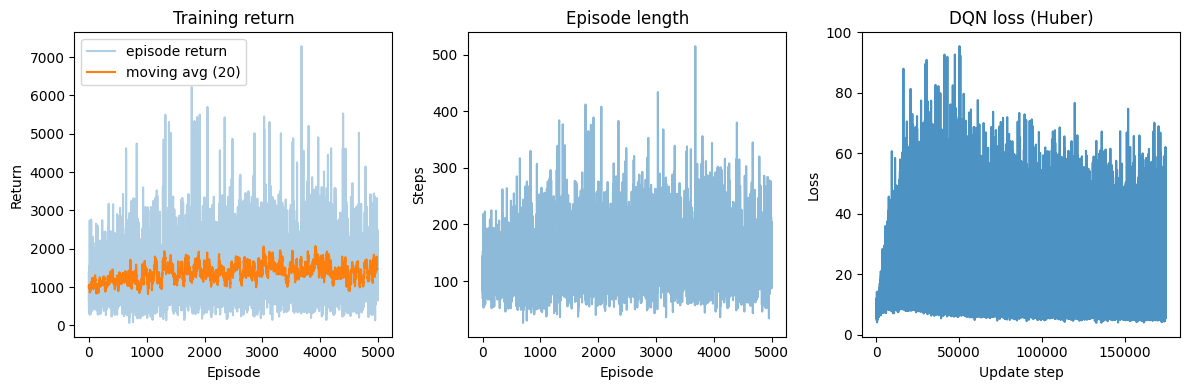

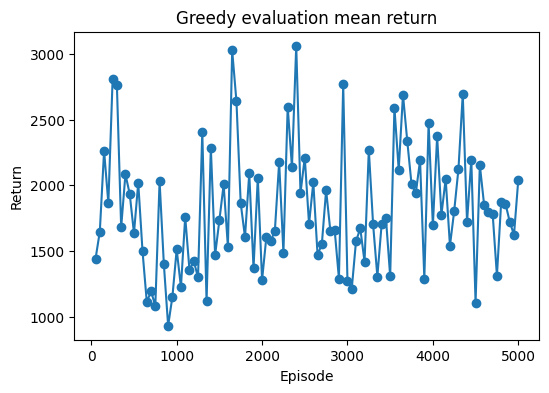

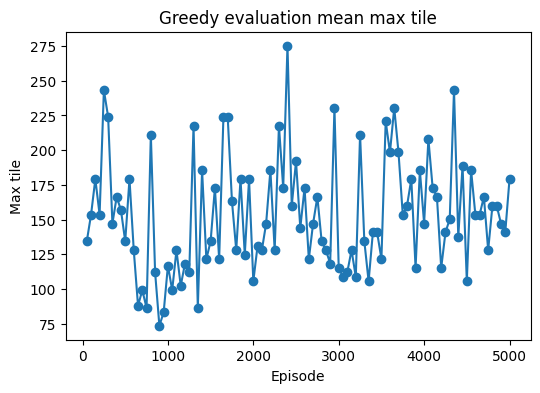

In [11]:
def moving_average(x, w=20):
    if len(x) < w:
        return np.asarray(x)
    return np.convolve(x, np.ones(w)/w, mode="valid")

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(episode_returns, alpha=0.35, label="episode return")
ma = moving_average(episode_returns, 20)
plt.plot(range(len(ma)), ma, label="moving avg (20)")
plt.title("Training return")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(episode_lengths, alpha=0.5)
plt.title("Episode length")
plt.xlabel("Episode")
plt.ylabel("Steps")

plt.subplot(1, 3, 3)
plt.plot(loss_history, alpha=0.8)
plt.title("DQN loss (Huber)")
plt.xlabel("Update step")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

if eval_returns:
    eval_eps, eval_vals = zip(*eval_returns)
    plt.figure(figsize=(6,4))
    plt.plot(eval_eps, eval_vals, marker="o")
    plt.title("Greedy evaluation mean return")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.show()

if eval_max_tiles:
    eval_eps, eval_tiles = zip(*eval_max_tiles)
    plt.figure(figsize=(6,4))
    plt.plot(eval_eps, eval_tiles, marker="o")
    plt.title("Greedy evaluation mean max tile")
    plt.xlabel("Episode")
    plt.ylabel("Max tile")
    plt.show()


## 7. Evaluate the best greedy policy and inspect the final board

After training, evaluate the restored **best model checkpoint** on a fresh seed.


In [12]:
eval_env = OpenSpiel2048Env(seed=999)
raw_obs = eval_env.reset(seed=999)
obs = build_model_obs(raw_obs, parse_board_numbers(eval_env.state), num_levels=BOARD_ONEHOT_LEVELS)
done = False
greedy_return = 0.0
rollout = []
best_max_tile = 0

while not done and len(rollout) < MAX_STEPS_PER_EPISODE:
    legal = eval_env.legal_actions()
    action = masked_greedy_action(q_net, obs, legal, num_actions, epsilon=0.0, device=DEVICE)
    next_raw_obs, reward, done, info = eval_env.step(action)
    next_obs = build_model_obs(next_raw_obs, info.get("board", None), num_levels=BOARD_ONEHOT_LEVELS)

    board = info["board"]
    if board is not None:
        best_max_tile = max(best_max_tile, int(np.max(board)))

    rollout.append({
        "action": action,
        "reward": reward,
        "legal_actions": legal,
        "board": board,
        "state_text": info["state_text"],
    })
    obs = next_obs
    greedy_return += reward

print("Greedy evaluation return:", greedy_return)
print("Rollout length:", len(rollout))
print("Max tile reached:", best_max_tile)
print()
eval_env.render()


Greedy evaluation return: 3896.0
Rollout length: 318
Max tile reached: 256

   64  256  128    2
    8   16   32  128
    2    4    8   32
    8    2    4    2



In [13]:

# Show a few last boards from the greedy rollout
n_show = min(5, len(rollout))
for i, step_info in enumerate(rollout[-n_show:], start=len(rollout)-n_show+1):
    print("=" * 60)
    print(f"Step {i} | action={step_info['action']} | reward={step_info['reward']:.1f}")
    if step_info["board"] is not None:
        print(step_info["board"])
    print(step_info["state_text"])

Step 314 | action=1 | reward=8.0
[[ 64 256 128   2]
 [  4  16  32 128]
 [  2   4   8  32]
 [  0   0   2   8]]
   64  256  128    2
    4   16   32  128
    2    4    8   32
    0    0    2    8

Step 315 | action=3 | reward=0.0
[[ 64 256 128   2]
 [  4  16  32 128]
 [  2   4   8  32]
 [  2   8   0   4]]
   64  256  128    2
    4   16   32  128
    2    4    8   32
    2    8    0    4

Step 316 | action=0 | reward=4.0
[[ 64 256 128   2]
 [  4  16  32 128]
 [  4   4   8  32]
 [  2   8   0   4]]
   64  256  128    2
    4   16   32  128
    4    4    8   32
    2    8    0    4

Step 317 | action=0 | reward=8.0
[[ 64 256 128   2]
 [  8  16  32 128]
 [  2   4   8  32]
 [  0   8   2   4]]
   64  256  128    2
    8   16   32  128
    2    4    8   32
    0    8    2    4

Step 318 | action=3 | reward=0.0
[[ 64 256 128   2]
 [  8  16  32 128]
 [  2   4   8  32]
 [  8   2   4   2]]
   64  256  128    2
    8   16   32  128
    2    4    8   32
    8    2    4    2



## 8. Save the model

You can download this checkpoint from Colab or store it to Google Drive.

In [14]:
checkpoint_path = "dqn_2048_baseline_plus_stable.pt"
torch.save(
    {
        "model_state_dict": q_net.state_dict(),
        "target_state_dict": target_net.state_dict(),
        "obs_dim": obs_dim,
        "num_actions": num_actions,
        "episode_returns": episode_returns,
        "episode_lengths": episode_lengths,
        "loss_history": loss_history,
        "eval_returns": eval_returns,
        "eval_max_tiles": eval_max_tiles,
        "best_eval_mean": best_eval_mean,
        "config": {
            "NUM_EPISODES": NUM_EPISODES,
            "BUFFER_SIZE": BUFFER_SIZE,
            "BATCH_SIZE": BATCH_SIZE,
            "GAMMA": GAMMA,
            "LR": LR,
            "TARGET_SYNC_EVERY": TARGET_SYNC_EVERY,
            "LEARN_START": LEARN_START,
            "LEARN_EVERY": LEARN_EVERY,
            "EPS_START": EPS_START,
            "EPS_END": EPS_END,
            "EPS_DECAY_STEPS": EPS_DECAY_STEPS,
            "MAX_STEPS_PER_EPISODE": MAX_STEPS_PER_EPISODE,
            "GRAD_CLIP": GRAD_CLIP,
            "HIDDEN_DIM": HIDDEN_DIM,
            "EVAL_EVERY": EVAL_EVERY,
            "NUM_EVAL_EPISODES": NUM_EVAL_EPISODES,
        },
    },
    checkpoint_path,
)
print("Saved checkpoint to:", checkpoint_path)


Saved checkpoint to: dqn_2048_baseline_plus_stable.pt
